# Sepsis Early-Warning — Explainability (SHAP)

Adds "why" to the sepsis model's hourly predictions. For a bedside tool, a raw risk
score isn't enough — a clinician needs to see which vitals or labs are driving the
alert to decide how to act on it.

**Prerequisite:** run `notebooks/04_sepsis_training.ipynb` first so the trained model
exists in `models/`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

model = joblib.load("models/sepsis_model.pkl")
feature_names = joblib.load("models/sepsis_feature_names.pkl")

test_df = pd.read_csv("data/sepsis_test.csv")
X_test = test_df[feature_names]

print(f"Loaded model and data: {X_test.shape}")

Loaded model and data: (310997, 31)


## 1. Build the explainer

Same approach as the readmission model — `TreeExplainer` for fast, exact SHAP values on
this XGBoost model. We sample rows from the test set rather than all 310K to keep this
notebook fast to re-run.

In [2]:
explainer = shap.TreeExplainer(model)

sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(sample)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (1000, 31)


## 2. Population-level view: which features matter most overall?

Worth checking this against clinical intuition: rolling vital-sign trends and lab
"was this test ordered" indicators should rank highly, since those reflect real signals
of clinical concern, not just noise.

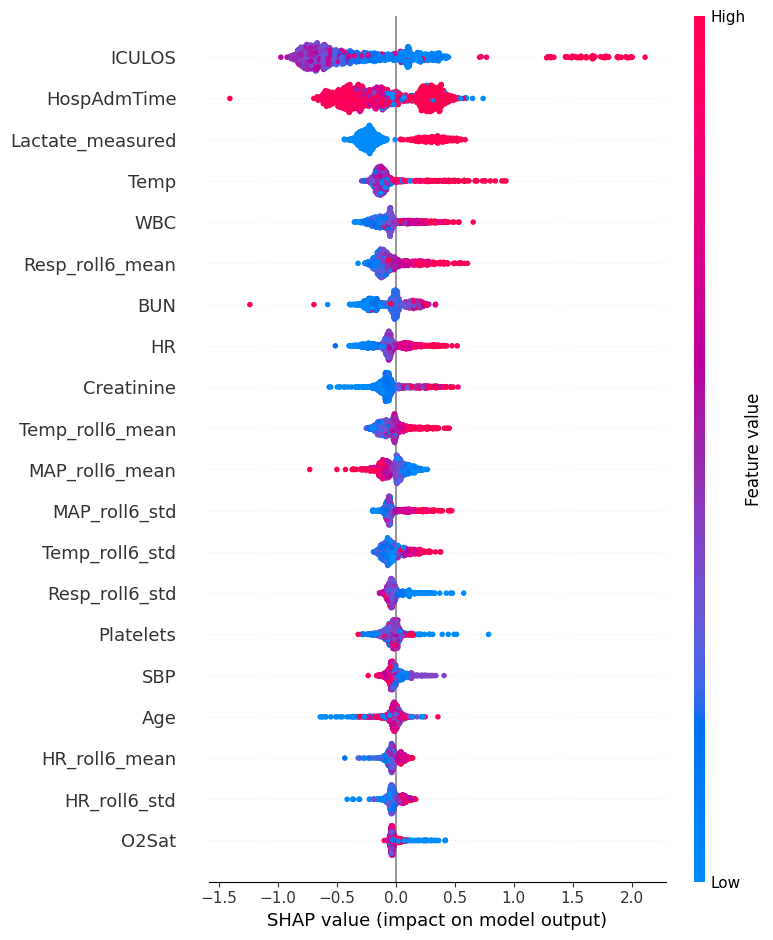

In [3]:
shap.summary_plot(shap_values, sample, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig("models/sepsis_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Individual patient-hour explanation

This is what powers the ICU monitoring tab's "why this alert" panel — for any single
patient-hour, a waterfall plot shows exactly which vitals/labs pushed the sepsis risk
score up or down.

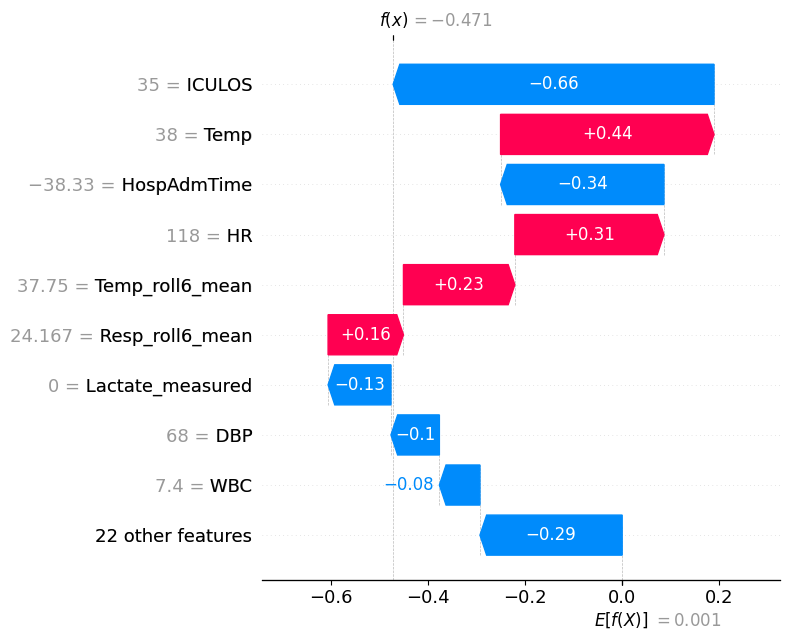

Predicted sepsis risk for this patient-hour: 38.4%


In [4]:
row_idx = 0  # change this to inspect a different patient-hour in the sample

explanation = shap.Explanation(
    values=shap_values[row_idx],
    base_values=explainer.expected_value,
    data=sample.iloc[row_idx],
    feature_names=feature_names,
)

shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.savefig("models/sepsis_shap_waterfall_example.png", dpi=150, bbox_inches="tight")
plt.show()

predicted_prob = model.predict_proba(sample.iloc[[row_idx]])[0, 1]
print(f"Predicted sepsis risk for this patient-hour: {predicted_prob:.1%}")

## 4. Save the explainer for the dashboard

Saved so the Streamlit dashboard can generate a live explanation for any patient's
current hour without recomputing SHAP from scratch each time.

In [5]:
joblib.dump(explainer, "models/sepsis_shap_explainer.pkl")
print("Saved SHAP explainer to models/sepsis_shap_explainer.pkl")

Saved SHAP explainer to models/sepsis_shap_explainer.pkl
